# Comparing all the models

All five models side by side. Reads whatever `results/preds_*_test.csv` files exist, so it works now and I just rerun it as the rest land. Nothing gets retrained.

The last part is the one that matters. Everyone scores around 0.98, so the real question is who still works on tweets with no trigger word in them.

In [12]:
!git clone -q -b part_4 https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git
%cd NLP-and-Language-Technologies

/content/NLP-and-Language-Technologies/NLP-and-Language-Technologies


In [13]:
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

from src import metrics as M
from src.save_preds import save_preds
from src.robustness import top_keywords

PROB_COLS = [f"p_{label}" for label in M.LABEL_ORDER]

## Step 1: Load the predictions

Everyone saved through `src/save_preds.py` so the columns match. I sort by `Tweet_ID` so the rows line up.

In [14]:
preds = {}
for path in sorted(glob.glob("reports/results/preds_*_test.csv")):
    name = Path(path).stem.replace("preds_", "").replace("_test", "")
    preds[name] = pd.read_csv(path).sort_values("Tweet_ID").reset_index(drop=True)

print("found:", list(preds))
for name, d in preds.items():
    print(f"  {name}: {len(d)} rows")

found: ['bilstm', 'distilbert', 'majority', 'textcnn', 'tfidf_logreg']
  bilstm: 5948 rows
  distilbert: 5948 rows
  majority: 5948 rows
  textcnn: 5948 rows
  tfidf_logreg: 5948 rows


## Step 2: Add the majority baseline

Always predicts the biggest class. Nothing to train, so I just build it here. It's the floor: ~82% accuracy from imbalance alone.

In [15]:
if "majority" not in preds and preds:
    ref = next(iter(preds.values()))
    probs = np.zeros((len(ref), len(M.LABEL_ORDER)))
    probs[:, 4] = 1.0
    out = save_preds("majority", ref["Tweet_ID"], probs, ref["true_id"])
    preds["majority"] = pd.read_csv(out).sort_values("Tweet_ID").reset_index(drop=True)
    print("made", out)

ids = [tuple(d["Tweet_ID"]) for d in preds.values()]
truth = [tuple(d["true_id"]) for d in preds.values()]
print("same tweets in every file:", len(set(ids)) == 1)
print("same labels in every file:", len(set(truth)) == 1)

same tweets in every file: True
same labels in every file: True


## Step 3: The table

All computed from the predictions with the shared `compute_metrics`, so no model is scored by different code.

Read macro F1, not accuracy.

In [16]:
rows = []
for name, d in preds.items():
    m = M.compute_metrics(d["true_id"], d["pred_id"])
    row = {"model": name, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"]}
    for label in M.LABEL_ORDER:
        row[f"f1_{label}"] = m["per_class_report"][label]["f1-score"]
    rows.append(row)

table = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
table.round(4)

,model,accuracy,macro_f1,f1_economic_violence,f1_emotional_violence,f1_harmful_traditional_practice,f1_physical_violence,f1_sexual_violence
0,textcnn,0.9995,0.9978,1.0000,0.9897,1.0000,0.9994,0.9997
1,distilbert,0.9993,0.9954,0.9841,0.9949,1.0000,0.9983,0.9997
2,tfidf_logreg,0.9970,0.9813,0.9697,0.9608,0.9825,0.9955,0.9983
3,bilstm,0.9963,0.9792,1.0000,0.9372,0.9655,0.9955,0.9979
4,majority,0.8235,0.1806,0.0000,0.0000,0.0000,0.0000,0.9032


## Step 4: Confusion matrices

One grid, all models. I draw my own so I don't overwrite Jean's Part 1 figures.

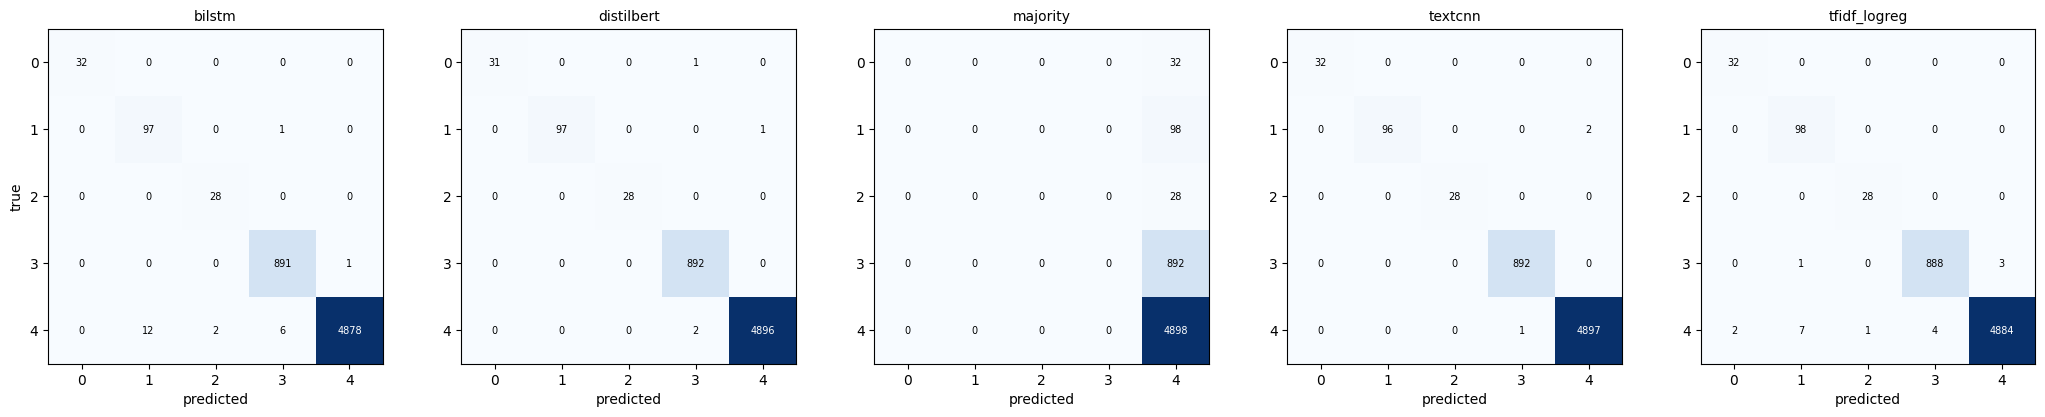

In [17]:
n = len(preds)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
axes = np.atleast_1d(axes)

for ax, (name, d) in zip(axes, preds.items()):
    cm = M.compute_metrics(d["true_id"], d["pred_id"])["confusion_matrix"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(range(5))
    ax.set_yticklabels(range(5))
    ax.set_xlabel("predicted")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() * 0.6 else "black")

axes[0].set_ylabel("true")
plt.tight_layout()
plt.savefig("reports/figures/comparison_confusion_matrices.png", dpi=150)
plt.show()

## Step 5: ROC curves

Needs the probabilities, not the labels. 5 classes so it's one against the rest, averaged into one line per model.

Averaged across classes, not tweets, otherwise `sexual_violence` drowns everything out.

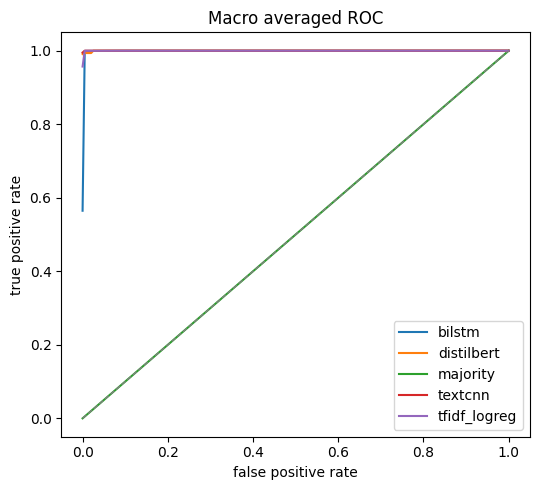

,model,auc_economic_violence,auc_emotional_violence,auc_harmful_traditional_practice,auc_physical_violence,auc_sexual_violence,macro_auc
0,textcnn,1.0000,0.9999,1.0000,1.0000,1.0000,1.0000
1,tfidf_logreg,1.0000,1.0000,1.0000,0.9999,0.9999,1.0000
2,distilbert,0.9993,1.0000,1.0000,1.0000,1.0000,0.9998
3,bilstm,1.0000,0.9997,0.9998,0.9999,0.9993,0.9998
4,majority,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000


In [18]:
grid = np.linspace(0, 1, 200)

def macro_roc(y, P):
    tprs = []
    for i in range(len(M.LABEL_ORDER)):
        fpr, tpr, _ = roc_curve((y == i).astype(int), P[:, i])
        tprs.append(np.interp(grid, fpr, tpr))
    return np.mean(tprs, axis=0)

auc_rows = []
plt.figure(figsize=(5.5, 5))

for name, d in preds.items():
    y = d["true_id"].values
    P = d[PROB_COLS].values
    plt.plot(grid, macro_roc(y, P), label=name)

    row = {"model": name}
    for i, label in enumerate(M.LABEL_ORDER):
        row[f"auc_{label}"] = roc_auc_score((y == i).astype(int), P[:, i])
    row["macro_auc"] = np.mean([row[f"auc_{l}"] for l in M.LABEL_ORDER])
    auc_rows.append(row)

plt.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Macro averaged ROC")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_roc.png", dpi=150)
plt.show()

auc = pd.DataFrame(auc_rows).sort_values("macro_auc", ascending=False).reset_index(drop=True)
auc.round(4)

## Step 6: Stress tests

I dropped the earlier idea of filtering out tweets that contain a keyword. Almost every tweet contains one, so the subset came out as a handful of tweets and told us nothing.

Instead each model runs the tests from `src/robustness.py` on its own and saves the result. This reads those files. Blank cells mean that model hasn't run them yet.

- **masked**: the strongest words per class replaced
- **random masked**: the same number of random words replaced, as the control
- **shuffled**: word order destroyed

In [19]:
import json as _json

VARIANTS = ["masked", "random_masked", "shuffled"]

stress = []
for name, d in preds.items():
    row = {"model": name, "normal": M.compute_metrics(d["true_id"], d["pred_id"])["macro_f1"]}
    for v in VARIANTS:
        f = Path(f"reports/results/{name}_{v}_test.json")
        row[v] = _json.load(open(f))["macro_f1"] if f.exists() else None
    stress.append(row)

stress = pd.DataFrame(stress)
stress.round(4)

,model,normal,masked,random_masked,shuffled
0,bilstm,0.9792,NaN,NaN,NaN
1,distilbert,0.9954,0.2463,0.9207,0.9857
2,majority,0.1806,NaN,NaN,NaN
3,textcnn,0.9978,0.3999,NaN,0.9978
4,tfidf_logreg,0.9813,0.2485,0.9351,0.9777


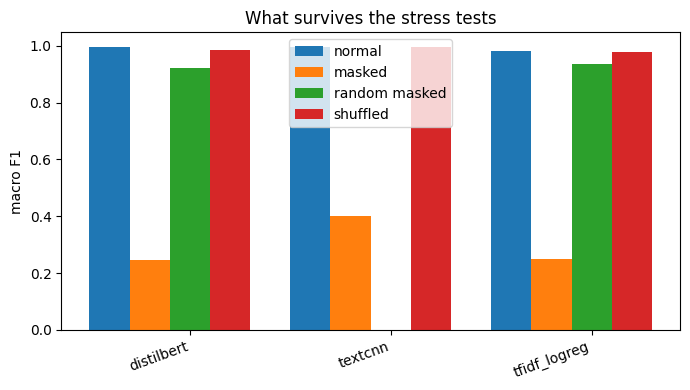

In [20]:
plot_me = stress.dropna(subset=VARIANTS, how="all")
cols = ["normal"] + VARIANTS
x = np.arange(len(plot_me))
width = 0.8 / len(cols)

plt.figure(figsize=(7, 4))
for k, col in enumerate(cols):
    plt.bar(x + (k - len(cols) / 2) * width, plot_me[col].fillna(0), width, label=col.replace("_", " "))

plt.xticks(x, plot_me["model"], rotation=20, ha="right")
plt.ylabel("macro F1")
plt.title("What survives the stress tests")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_stress_tests.png", dpi=150)
plt.show()

## Step 7: What's being missed

The tweets each model gets wrong, for the error analysis.

In [21]:
text = pd.read_csv("data/processed/train_cleaned.csv")
lookup = text.set_index("Tweet_ID")["tweet_clean"]

for name, d in preds.items():
    wrong = d[d["true_id"] != d["pred_id"]]
    print(f"\n=== {name}: {len(wrong)} wrong out of {len(d)} ===")
    for _, r in wrong.head(3).iterrows():
        print(f"  {M.LABEL_ORDER[r['true_id']]} -> said {M.LABEL_ORDER[r['pred_id']]}")
        print(f"  {lookup[r['Tweet_ID']][:200]}")


=== bilstm: 22 wrong out of 5948 ===
  sexual_violence -> said physical_violence
  u may be right. but if she claims her husband beats her, indulges in un natural sex, had raped their minor daughter, his father rapes me, divorce is least worry of her husband. he will be put straight
  sexual_violence -> said emotional_violence
  my rapist flipped out when he lost control over my driving when i left him and stalked me in his car, followed by his friends. to this day, i do not know what manipulation he used to convince them i d
  sexual_violence -> said physical_violence
  this nigga set my house on fire, raped my pet ostrich and he beats me up every day 😔😔

=== distilbert: 4 wrong out of 5948 ===
  sexual_violence -> said physical_violence
  u may be right. but if she claims her husband beats her, indulges in un natural sex, had raped their minor daughter, his father rapes me, divorce is least worry of her husband. he will be put straight
  emotional_violence -> said sexual_violence
  

In [22]:
table.to_csv("reports/results/model_comparison_all.csv", index=False)
auc.to_csv("reports/results/roc_auc_all.csv", index=False)
stress.to_csv("reports/results/stress_test_comparison.csv", index=False)
print("saved 3 tables and 3 figures")

saved 3 tables and 3 figures
